### Perbandingan Hasil Model

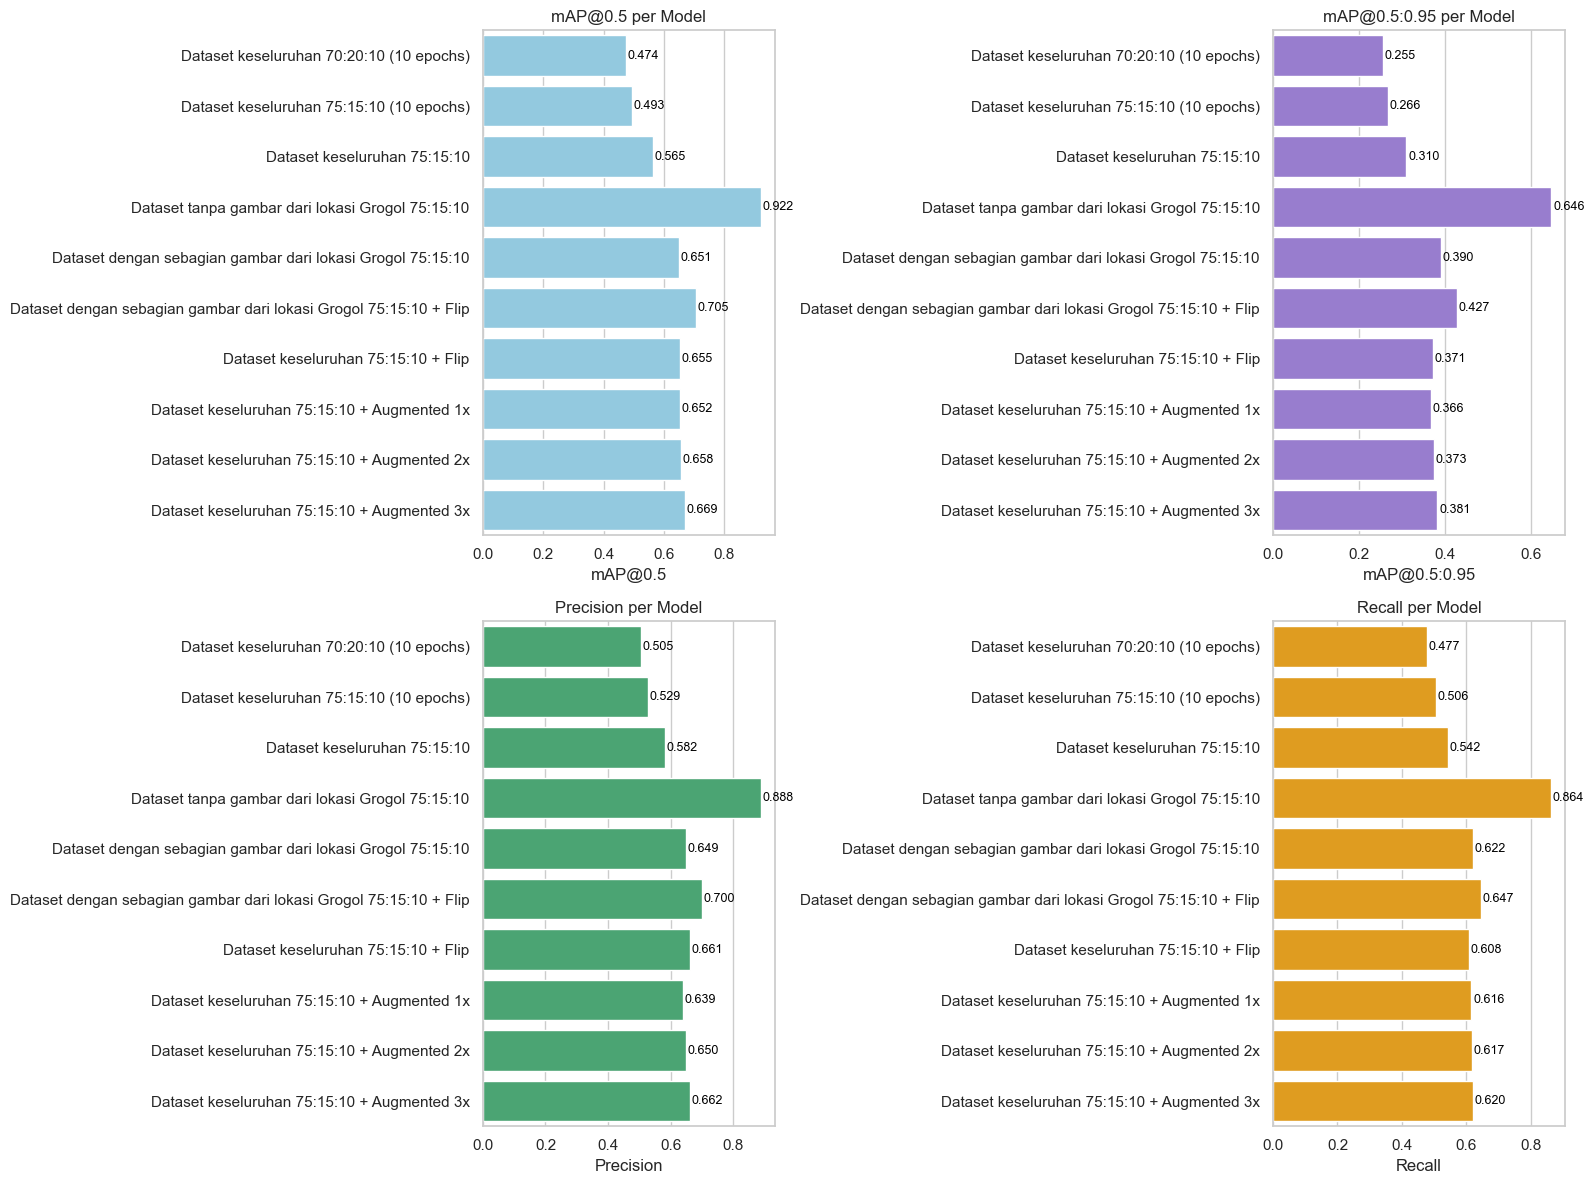

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Daftar path ke file results.csv
csv_paths = [
    "runs/d_70_20_10_train/y11n_batch16_epochs10/results.csv",
    "runs/d_75_15_10_train/y11n_batch16_epochs10/results.csv",
    "runs/d_75_15_10_train/y11n_batch16_epochs100/results.csv",
    "runs/withoutgrogol_retrain/y11n_batch16_epochs100/results.csv",
    "runs/datalabelstudio_75_15_10_clean_train/y11n_batch16_epochs100/results.csv",
    "runs/datalabelstudio_75_15_10_clean_flip_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_flip_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_2x_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_3x_train/y11n_batch16_epochs100/results.csv",
]

# Label model untuk ditampilkan di grafik
labels = [
    "Dataset keseluruhan 70:20:10 (10 epochs)",
    "Dataset keseluruhan 75:15:10 (10 epochs)",
    "Dataset keseluruhan 75:15:10",
    "Dataset tanpa gambar dari lokasi Grogol 75:15:10",
    "Dataset dengan sebagian gambar dari lokasi Grogol 75:15:10",
    "Dataset dengan sebagian gambar dari lokasi Grogol 75:15:10 + Flip",
    "Dataset keseluruhan 75:15:10 + Flip",
    "Dataset keseluruhan 75:15:10 + Augmented 1x",
    "Dataset keseluruhan 75:15:10 + Augmented 2x",
    "Dataset keseluruhan 75:15:10 + Augmented 3x",
]

# List untuk menyimpan semua data
all_data = []

# Baca semua CSV
for path, label in zip(csv_paths, labels):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()  # Bersihkan spasi

        try:
            # Ambil epoch dengan nilai mAP50 tertinggi
            best = df.loc[df["metrics/mAP50(B)"].idxmax()]
            all_data.append({
                "Label": label,
                "Precision": best["metrics/precision(B)"],
                "Recall": best["metrics/recall(B)"],
                "mAP50": best["metrics/mAP50(B)"],
                "mAP50-95": best["metrics/mAP50-95(B)"]
            })
        except KeyError as e:
            print(f"Kolom tidak ditemukan di {path}: {e}")
    else:
        print(f"Tidak ditemukan: {path}")

# Gabungkan ke DataFrame
results_df = pd.DataFrame(all_data)

# Fungsi untuk menambahkan angka di atas batang
def add_bar_labels(ax, fmt="%.3f"):
    for container in ax.containers:
        for bar in container:
            width = bar.get_width()
            ax.text(width + 0.005, bar.get_y() + bar.get_height()/2,
                    fmt % width,
                    ha='left', va='center', fontsize=9, color='black')

# Visualisasi
sns.set(style="whitegrid")
plt.figure(figsize=(16, 12))

# mAP@0.5
plt.subplot(2, 2, 1)
ax1 = sns.barplot(x="mAP50", y="Label", data=results_df, color="skyblue")
plt.title("mAP@0.5 per Model")
plt.xlabel("mAP@0.5")
plt.ylabel("")
add_bar_labels(ax1)

# mAP@0.5:0.95
plt.subplot(2, 2, 2)
ax2 = sns.barplot(x="mAP50-95", y="Label", data=results_df, color="mediumpurple")
plt.title("mAP@0.5:0.95 per Model")
plt.xlabel("mAP@0.5:0.95")
plt.ylabel("")
add_bar_labels(ax2)

# Precision
plt.subplot(2, 2, 3)
ax3 = sns.barplot(x="Precision", y="Label", data=results_df, color="mediumseagreen")
plt.title("Precision per Model")
plt.xlabel("Precision")
plt.ylabel("")
add_bar_labels(ax3)

# Recall
plt.subplot(2, 2, 4)
ax4 = sns.barplot(x="Recall", y="Label", data=results_df, color="orange")
plt.title("Recall per Model")
plt.xlabel("Recall")
plt.ylabel("")
add_bar_labels(ax4)

plt.tight_layout()
plt.show()

### Akurasi Model Terhadap Data Splitting

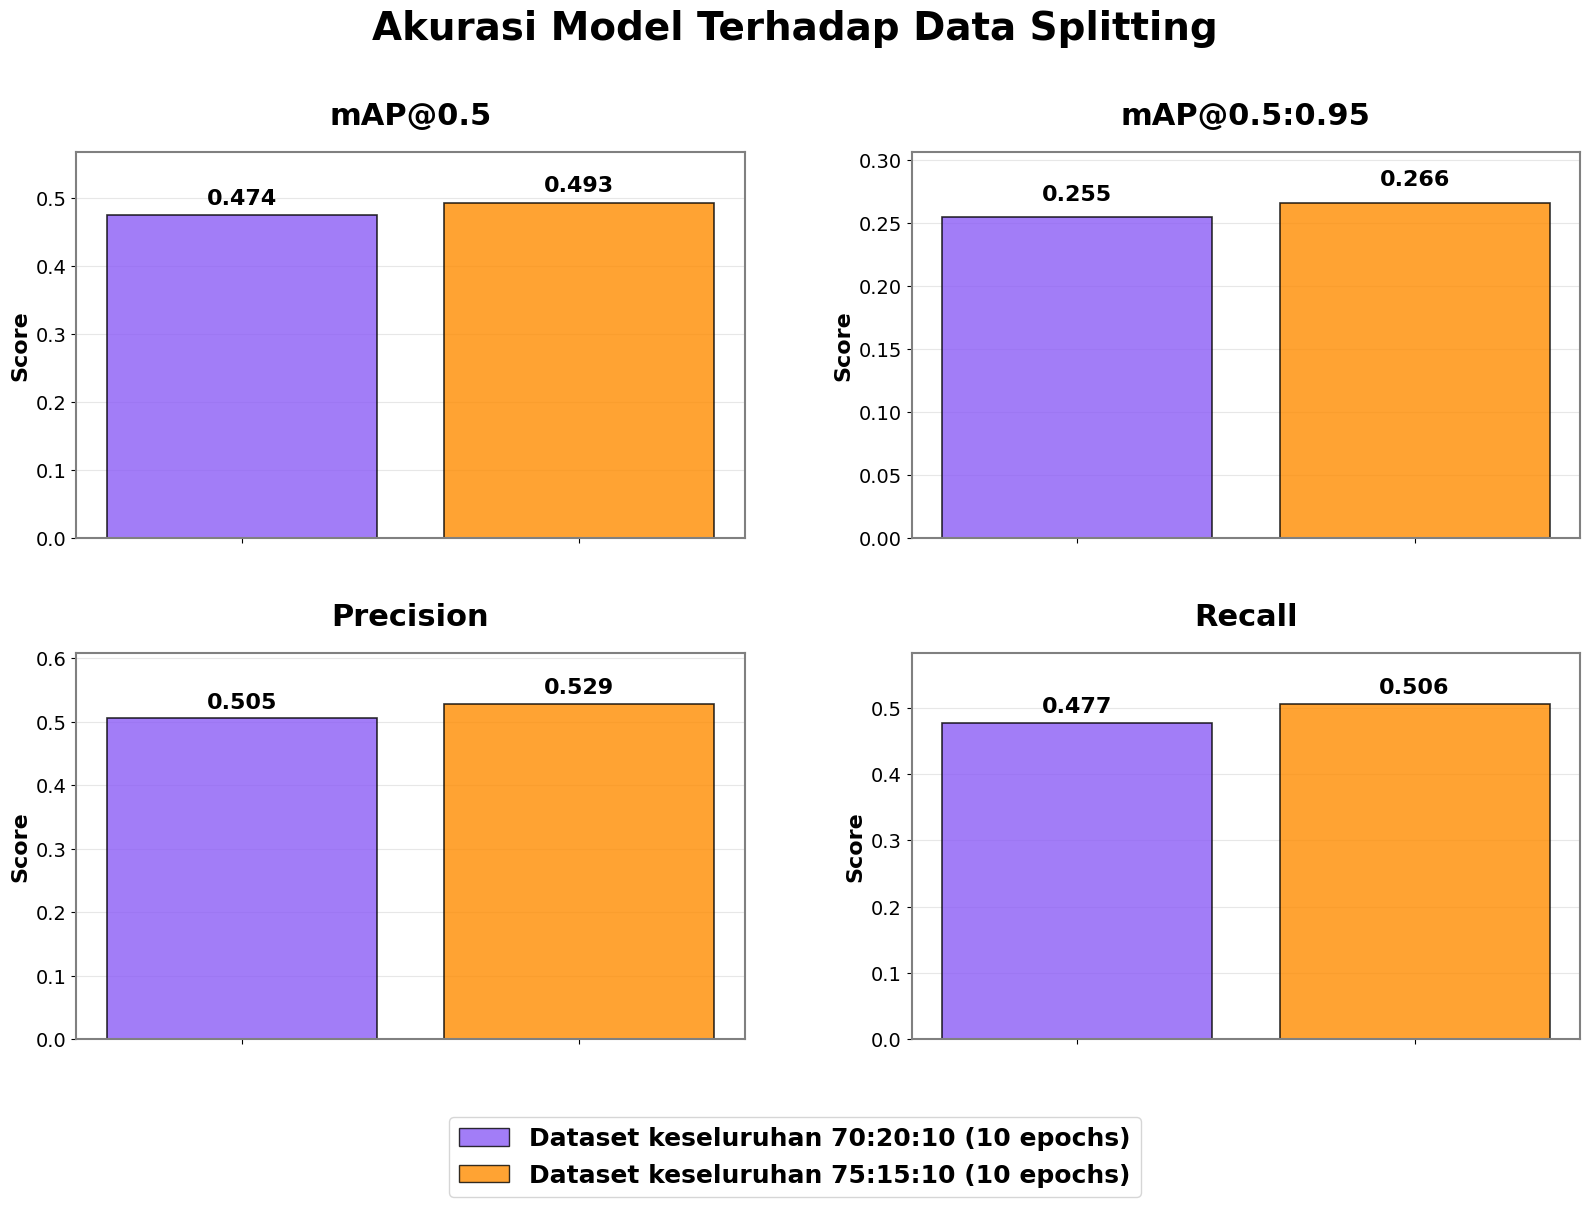


HASIL PERBANDINGAN MODEL

Dataset keseluruhan 70:20:10 (10 epochs):
  mAP@0.5      : 0.474
  mAP@0.5:0.95 : 0.255
  Precision    : 0.505
  Recall       : 0.477

Dataset keseluruhan 75:15:10 (10 epochs):
  mAP@0.5      : 0.493
  mAP@0.5:0.95 : 0.266
  Precision    : 0.529
  Recall       : 0.506


In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Daftar path ke file results.csv
csv_paths = [
    "runs/d_70_20_10_train/y11n_batch16_epochs10/results.csv",
    "runs/d_75_15_10_train/y11n_batch16_epochs10/results.csv",
]

# Label model untuk ditampilkan di grafik
labels = [
    "Dataset keseluruhan 70:20:10 (10 epochs)",
    "Dataset keseluruhan 75:15:10 (10 epochs)",
]

# List untuk menyimpan semua data
all_data = []

# Baca semua CSV
for path, label in zip(csv_paths, labels):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()  # Bersihkan spasi

        try:
            # Ambil epoch dengan nilai mAP50 tertinggi
            best = df.loc[df["metrics/mAP50(B)"].idxmax()]
            all_data.append({
                "Dataset": label,
                "Precision": best["metrics/precision(B)"],
                "Recall": best["metrics/recall(B)"],
                "mAP50": best["metrics/mAP50(B)"],
                "mAP50-95": best["metrics/mAP50-95(B)"]
            })
        except KeyError as e:
            print(f"Kolom tidak ditemukan di {path}: {e}")
    else:
        print(f"Tidak ditemukan: {path}")

# Gabungkan ke DataFrame
results_df = pd.DataFrame(all_data)

# Warna untuk setiap dataset (2 warna berbeda)
colors = ['#8B5CF6', '#FF8C00']  # Ungu dan orange

# Fungsi untuk menambahkan label di atas bar
def add_value_labels(ax, bars, fmt="%.3f"):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                fmt % height,
                ha='center', va='bottom', fontsize=16, fontweight='bold')

# Set style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Akurasi Model Terhadap Data Splitting', fontsize=28, fontweight='bold', y=0.98)

# Metrics untuk diplot
metrics = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
titles = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']

# Plot setiap metric
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Buat bar chart vertikal
    x_pos = np.arange(len(results_df))
    bars = ax.bar(x_pos, results_df[metric], 
                  color=[colors[i % len(colors)] for i in range(len(results_df))],
                  alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Tambahkan label nilai di atas bar
    add_value_labels(ax, bars)
    
    # Styling
    ax.set_title(title, fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Score', fontsize=16, fontweight='bold')
    ax.set_xlabel('')  # Hapus label X-axis
    
    # Hapus x-axis labels (tick labels)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([])
    
    # Grid dan styling
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Set y-axis limit dengan sedikit ruang di atas untuk label
    max_val = results_df[metric].max()
    ax.set_ylim(0, max_val * 1.15)
    
    # Format y-axis
    ax.tick_params(axis='y', labelsize=14)
    
    # Tambahkan border pada subplot
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('gray')

# Adjust layout
plt.tight_layout(rect=[0, 0.1, 1, 0.96])  # Beri ruang di bawah untuk legend
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Tambahkan legend untuk warna dataset di bawah
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[i % len(colors)], 
                                alpha=0.8, edgecolor='black') 
                  for i in range(len(results_df))]
legend = fig.legend(legend_elements, results_df['Dataset'], 
                   loc='lower center', bbox_to_anchor=(0.5, -0.02), 
                   ncol=1, fontsize=18)

# Set font weight untuk legend text secara manual
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.show()

# Print hasil dalam bentuk tabel
print("\n" + "="*60)
print("HASIL PERBANDINGAN MODEL")
print("="*60)
for idx, row in results_df.iterrows():
    print(f"\n{row['Dataset']}:")
    print(f"  mAP@0.5      : {row['mAP50']:.3f}")
    print(f"  mAP@0.5:0.95 : {row['mAP50-95']:.3f}")
    print(f"  Precision    : {row['Precision']:.3f}")
    print(f"  Recall       : {row['Recall']:.3f}")
print("="*60)

### Akurasi Model Terhadap Hasil Pelabelan Dataset

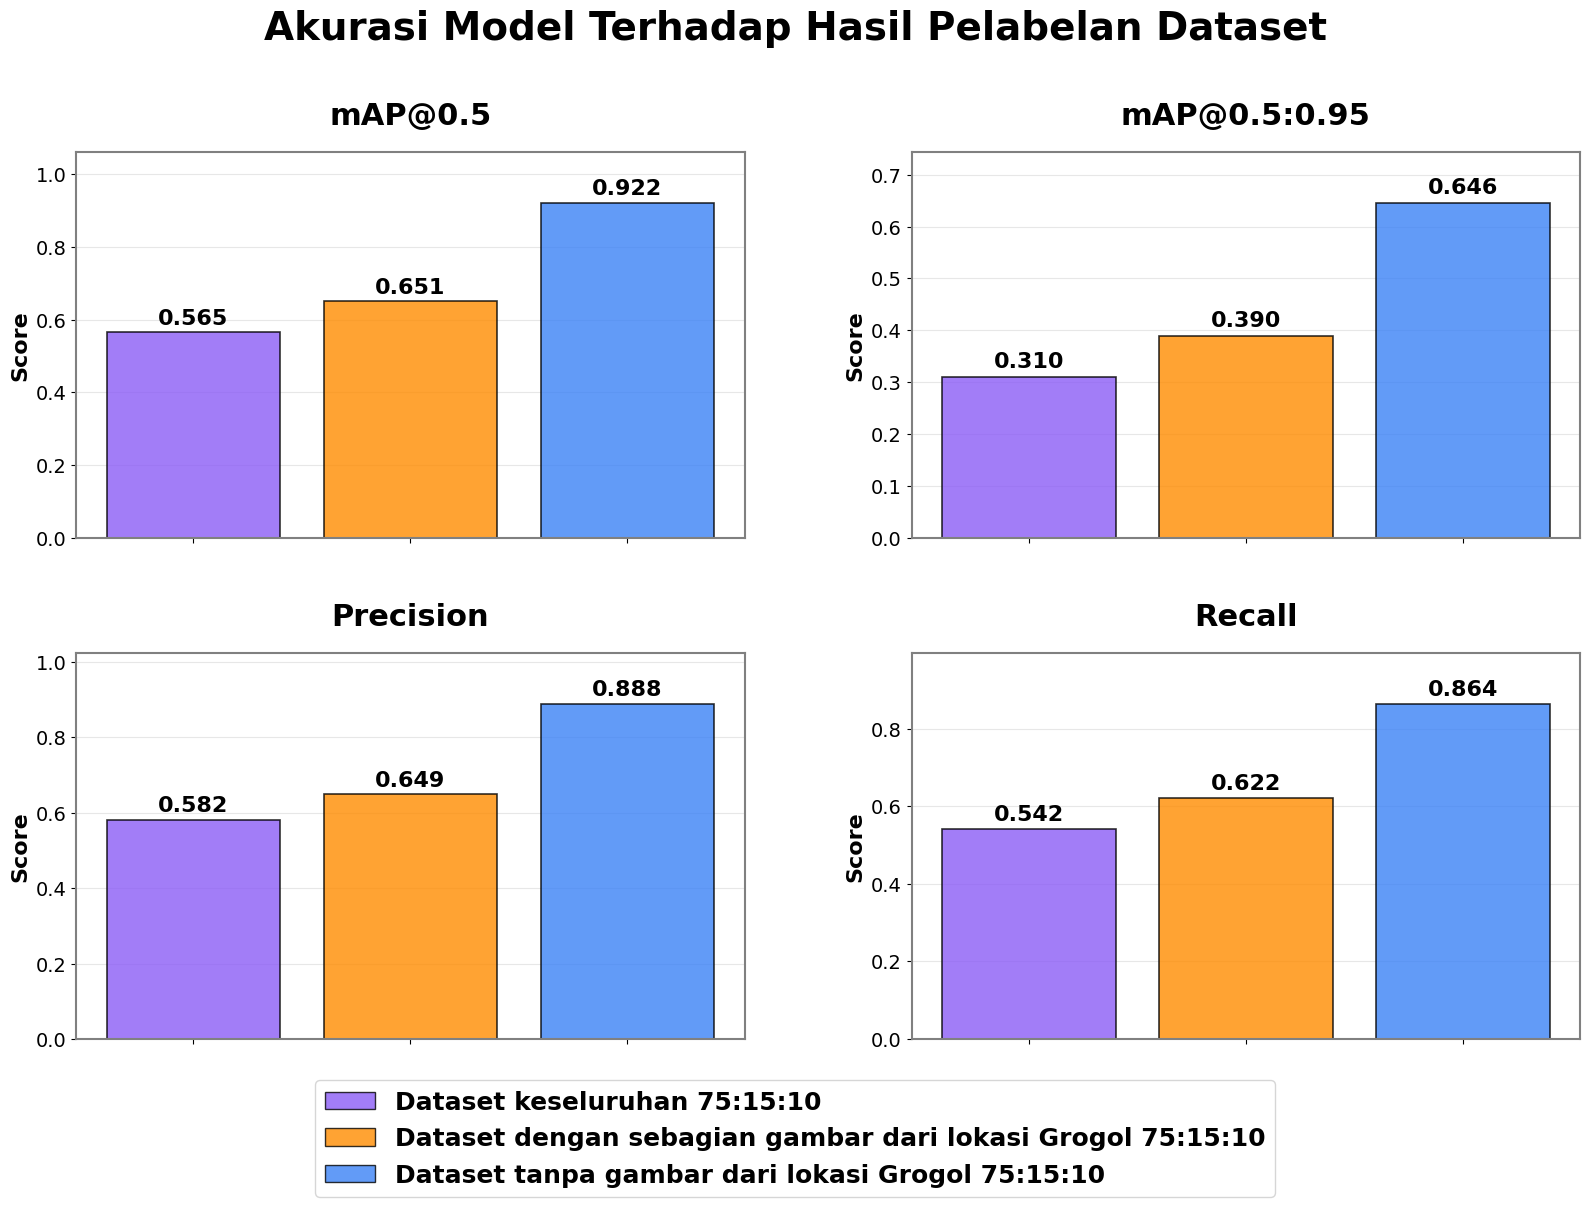


HASIL PERBANDINGAN MODEL

Dataset keseluruhan 75:15:10:
  mAP@0.5      : 0.565
  mAP@0.5:0.95 : 0.310
  Precision    : 0.582
  Recall       : 0.542

Dataset dengan sebagian gambar dari lokasi Grogol 75:15:10:
  mAP@0.5      : 0.651
  mAP@0.5:0.95 : 0.390
  Precision    : 0.649
  Recall       : 0.622

Dataset tanpa gambar dari lokasi Grogol 75:15:10:
  mAP@0.5      : 0.922
  mAP@0.5:0.95 : 0.646
  Precision    : 0.888
  Recall       : 0.864


In [108]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Daftar path ke file results.csv
csv_paths = [
    "runs/d_75_15_10_train/y11n_batch16_epochs100/results.csv",
    "runs/datalabelstudio_75_15_10_clean_train/y11n_batch16_epochs100/results.csv",
    "runs/withoutgrogol_retrain/y11n_batch16_epochs100/results.csv",
]

# Label model untuk ditampilkan di grafik
labels = [
    "Dataset keseluruhan 75:15:10",
    "Dataset dengan sebagian gambar dari lokasi Grogol 75:15:10",
    "Dataset tanpa gambar dari lokasi Grogol 75:15:10",
]

# List untuk menyimpan semua data
all_data = []

# Baca semua CSV
for path, label in zip(csv_paths, labels):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()  # Bersihkan spasi

        try:
            # Ambil epoch dengan nilai mAP50 tertinggi
            best = df.loc[df["metrics/mAP50(B)"].idxmax()]
            all_data.append({
                "Dataset": label,
                "Precision": best["metrics/precision(B)"],
                "Recall": best["metrics/recall(B)"],
                "mAP50": best["metrics/mAP50(B)"],
                "mAP50-95": best["metrics/mAP50-95(B)"]
            })
        except KeyError as e:
            print(f"Kolom tidak ditemukan di {path}: {e}")
    else:
        print(f"Tidak ditemukan: {path}")

# Gabungkan ke DataFrame
results_df = pd.DataFrame(all_data)

# Warna untuk setiap dataset (3 warna berbeda)
colors = ['#8B5CF6', '#FF8C00', '#3B82F6']  # Ungu, orange, biru

# Fungsi untuk menambahkan label di atas bar
def add_value_labels(ax, bars, fmt="%.3f"):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                fmt % height,
                ha='center', va='bottom', fontsize=16, fontweight='bold')

# Set style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Akurasi Model Terhadap Hasil Pelabelan Dataset', fontsize=28, fontweight='bold', y=0.98)

# Metrics untuk diplot
metrics = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
titles = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']

# Plot setiap metric
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Buat bar chart vertikal
    x_pos = np.arange(len(results_df))
    bars = ax.bar(x_pos, results_df[metric], 
                  color=[colors[i % len(colors)] for i in range(len(results_df))],
                  alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Tambahkan label nilai di atas bar
    add_value_labels(ax, bars)
    
    # Styling
    ax.set_title(title, fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Score', fontsize=16, fontweight='bold')
    ax.set_xlabel('')  # Hapus label X-axis
    
    # Hapus x-axis labels (tick labels)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([])
    
    # Grid dan styling
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Set y-axis limit dengan sedikit ruang di atas untuk label
    max_val = results_df[metric].max()
    ax.set_ylim(0, max_val * 1.15)
    
    # Format y-axis
    ax.tick_params(axis='y', labelsize=14)
    
    # Tambahkan border pada subplot
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('gray')

# Adjust layout
plt.tight_layout(rect=[0, 0.1, 1, 0.96])  # Beri ruang di bawah untuk legend
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Tambahkan legend untuk warna dataset di bawah
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[i % len(colors)], 
                                alpha=0.8, edgecolor='black') 
                  for i in range(len(results_df))]
legend = fig.legend(legend_elements, results_df['Dataset'], 
                   loc='lower center', bbox_to_anchor=(0.5, -0.02), 
                   ncol=1, fontsize=18)

# Set font weight untuk legend text secara manual
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.show()

# Print hasil dalam bentuk tabel
print("\n" + "="*60)
print("HASIL PERBANDINGAN MODEL")
print("="*60)
for idx, row in results_df.iterrows():
    print(f"\n{row['Dataset']}:")
    print(f"  mAP@0.5      : {row['mAP50']:.3f}")
    print(f"  mAP@0.5:0.95 : {row['mAP50-95']:.3f}")
    print(f"  Precision    : {row['Precision']:.3f}")
    print(f"  Recall       : {row['Recall']:.3f}")
print("="*60)

### Hasil Akurasi Model Terhadap Augmentasi

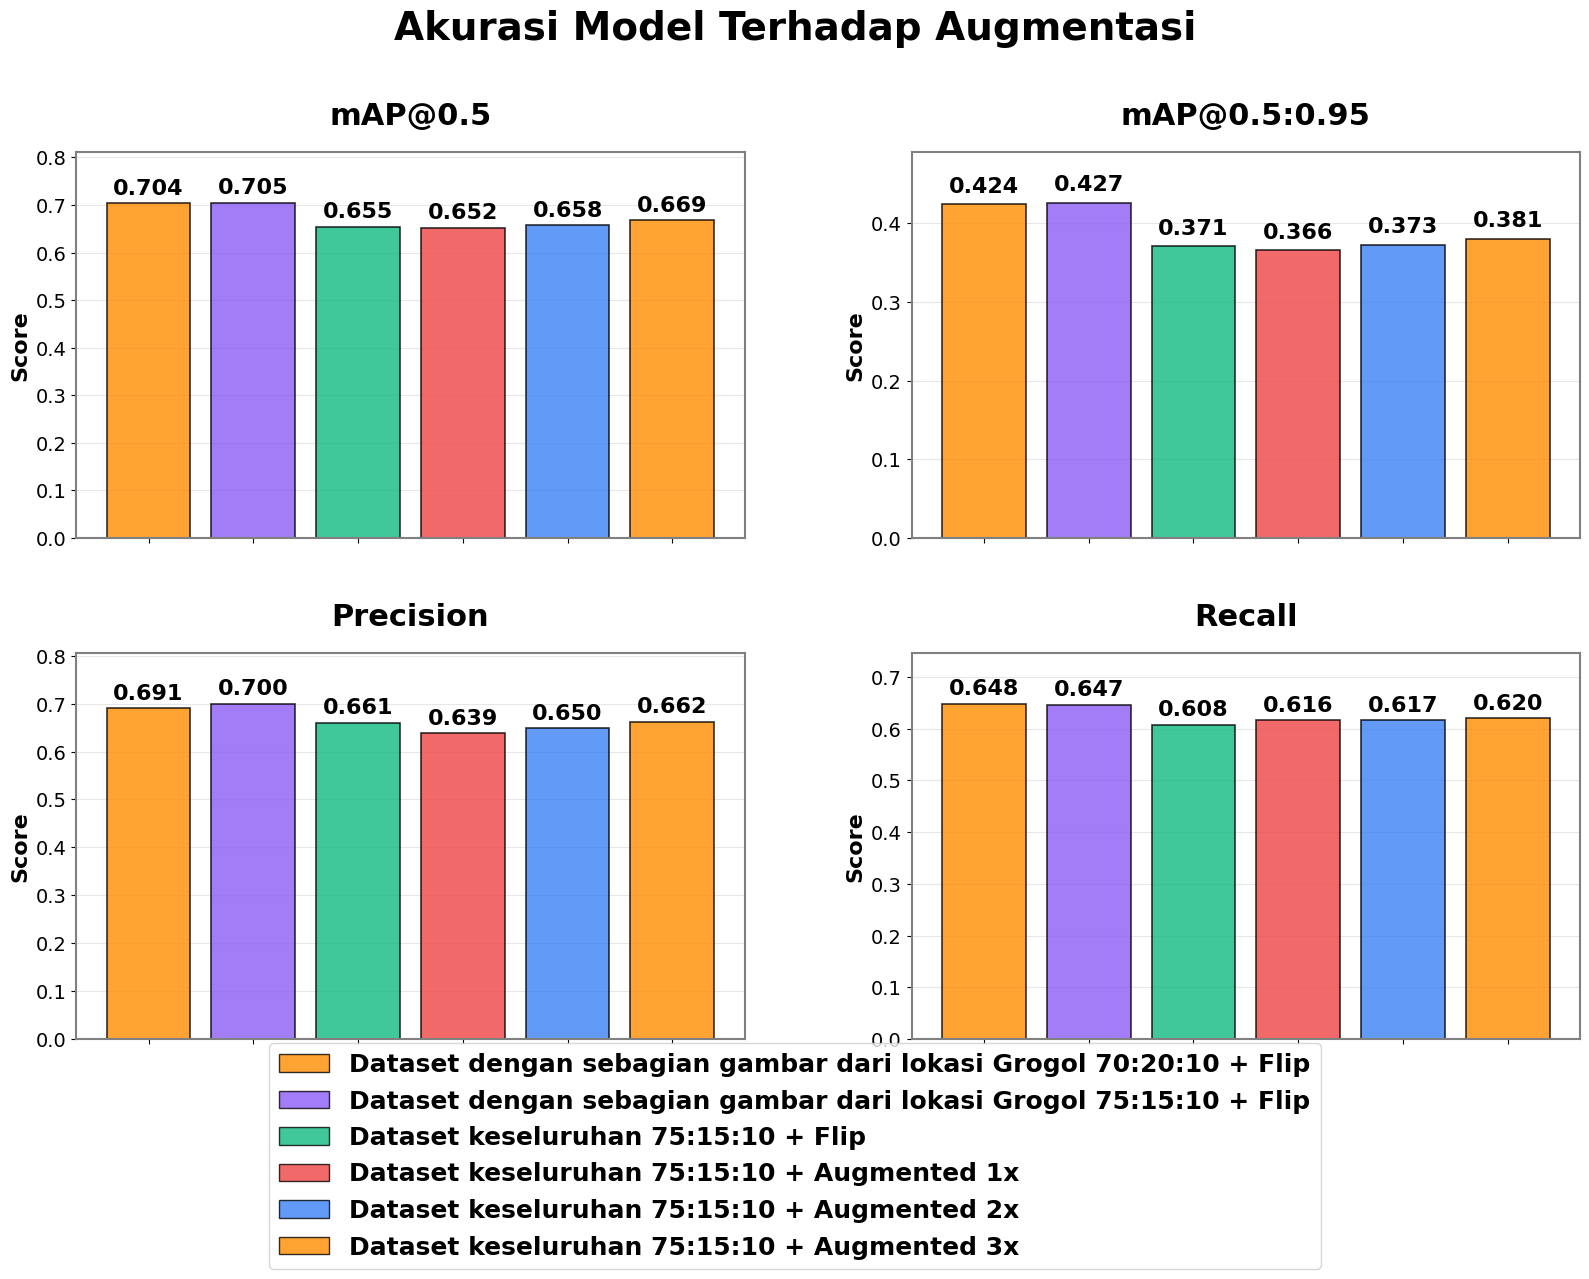


HASIL PERBANDINGAN MODEL

Dataset dengan sebagian gambar dari lokasi Grogol 70:20:10 + Flip:
  mAP@0.5      : 0.704
  mAP@0.5:0.95 : 0.424
  Precision    : 0.691
  Recall       : 0.648

Dataset dengan sebagian gambar dari lokasi Grogol 75:15:10 + Flip:
  mAP@0.5      : 0.705
  mAP@0.5:0.95 : 0.427
  Precision    : 0.700
  Recall       : 0.647

Dataset keseluruhan 75:15:10 + Flip:
  mAP@0.5      : 0.655
  mAP@0.5:0.95 : 0.371
  Precision    : 0.661
  Recall       : 0.608

Dataset keseluruhan 75:15:10 + Augmented 1x:
  mAP@0.5      : 0.652
  mAP@0.5:0.95 : 0.366
  Precision    : 0.639
  Recall       : 0.616

Dataset keseluruhan 75:15:10 + Augmented 2x:
  mAP@0.5      : 0.658
  mAP@0.5:0.95 : 0.373
  Precision    : 0.650
  Recall       : 0.617

Dataset keseluruhan 75:15:10 + Augmented 3x:
  mAP@0.5      : 0.669
  mAP@0.5:0.95 : 0.381
  Precision    : 0.662
  Recall       : 0.620


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Daftar path ke file results.csv
csv_paths = [
    "runs/dataset_clean_flip_retrain/y11n_batch16_epochs100/results.csv",
    "runs/datalabelstudio_75_15_10_clean_flip_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_flip_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_2x_train/y11n_batch16_epochs100/results.csv",
    "runs/dataset_75_15_10_augmented_3x_train/y11n_batch16_epochs100/results.csv",
]

# Label model untuk ditampilkan di grafik
labels = [
    "Dataset dengan sebagian gambar dari lokasi Grogol 70:20:10 + Flip",
    "Dataset dengan sebagian gambar dari lokasi Grogol 75:15:10 + Flip",
    "Dataset keseluruhan 75:15:10 + Flip",
    "Dataset keseluruhan 75:15:10 + Augmented 1x",
    "Dataset keseluruhan 75:15:10 + Augmented 2x",
    "Dataset keseluruhan 75:15:10 + Augmented 3x",
]

# List untuk menyimpan semua data
all_data = []

# Baca semua CSV
for path, label in zip(csv_paths, labels):
    if os.path.exists(path):
        df = pd.read_csv(path)
        df.columns = df.columns.str.strip()  # Bersihkan spasi

        try:
            # Ambil epoch dengan nilai mAP50 tertinggi
            best = df.loc[df["metrics/mAP50(B)"].idxmax()]
            all_data.append({
                "Dataset": label,
                "Precision": best["metrics/precision(B)"],
                "Recall": best["metrics/recall(B)"],
                "mAP50": best["metrics/mAP50(B)"],
                "mAP50-95": best["metrics/mAP50-95(B)"]
            })
        except KeyError as e:
            print(f"Kolom tidak ditemukan di {path}: {e}")
    else:
        print(f"Tidak ditemukan: {path}")

# Gabungkan ke DataFrame
results_df = pd.DataFrame(all_data)

# Warna untuk setiap dataset (5 warna berbeda)
colors = ['#FF8C00','#8B5CF6', '#10B981', '#EF4444', '#3B82F6']  # Ungu, orange, hijau, merah, biru

# Fungsi untuk menambahkan label di atas bar
def add_value_labels(ax, bars, fmt="%.3f"):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                fmt % height,
                ha='center', va='bottom', fontsize=16, fontweight='bold')

# Set style
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Akurasi Model Terhadap Augmentasi', fontsize=28, fontweight='bold', y=0.98)

# Metrics untuk diplot
metrics = ['mAP50', 'mAP50-95', 'Precision', 'Recall']
titles = ['mAP@0.5', 'mAP@0.5:0.95', 'Precision', 'Recall']

# Plot setiap metric
for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    # Buat bar chart vertikal
    x_pos = np.arange(len(results_df))
    bars = ax.bar(x_pos, results_df[metric], 
                  color=[colors[i % len(colors)] for i in range(len(results_df))],
                  alpha=0.8, edgecolor='black', linewidth=1.2)
    
    # Tambahkan label nilai di atas bar
    add_value_labels(ax, bars)
    
    # Styling
    ax.set_title(title, fontsize=22, fontweight='bold', pad=20)
    ax.set_ylabel('Score', fontsize=16, fontweight='bold')
    ax.set_xlabel('')  # Hapus label X-axis
    
    # Hapus x-axis labels (tick labels)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([])
    
    # Grid dan styling
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_axisbelow(True)
    
    # Set y-axis limit dengan sedikit ruang di atas untuk label
    max_val = results_df[metric].max()
    ax.set_ylim(0, max_val * 1.15)
    
    # Format y-axis
    ax.tick_params(axis='y', labelsize=14)
    
    # Tambahkan border pada subplot
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('gray')

# Adjust layout
plt.tight_layout(rect=[0, 0.1, 1, 0.96])  # Beri ruang di bawah untuk legend
plt.subplots_adjust(hspace=0.3, wspace=0.25)

# Tambahkan legend untuk warna dataset di bawah
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[i % len(colors)], 
                                alpha=0.8, edgecolor='black') 
                  for i in range(len(results_df))]
legend = fig.legend(legend_elements, results_df['Dataset'], 
                   loc='lower center', bbox_to_anchor=(0.5, -0.08), 
                   ncol=1, fontsize=18)

# Set font weight untuk legend text secara manual
for text in legend.get_texts():
    text.set_fontweight('bold')

plt.show()

# Print hasil dalam bentuk tabel
print("\n" + "="*60)
print("HASIL PERBANDINGAN MODEL")
print("="*60)
for idx, row in results_df.iterrows():
    print(f"\n{row['Dataset']}:")
    print(f"  mAP@0.5      : {row['mAP50']:.3f}")
    print(f"  mAP@0.5:0.95 : {row['mAP50-95']:.3f}")
    print(f"  Precision    : {row['Precision']:.3f}")
    print(f"  Recall       : {row['Recall']:.3f}")
print("="*60)

### Perbandingan Hasil PR_curve.png

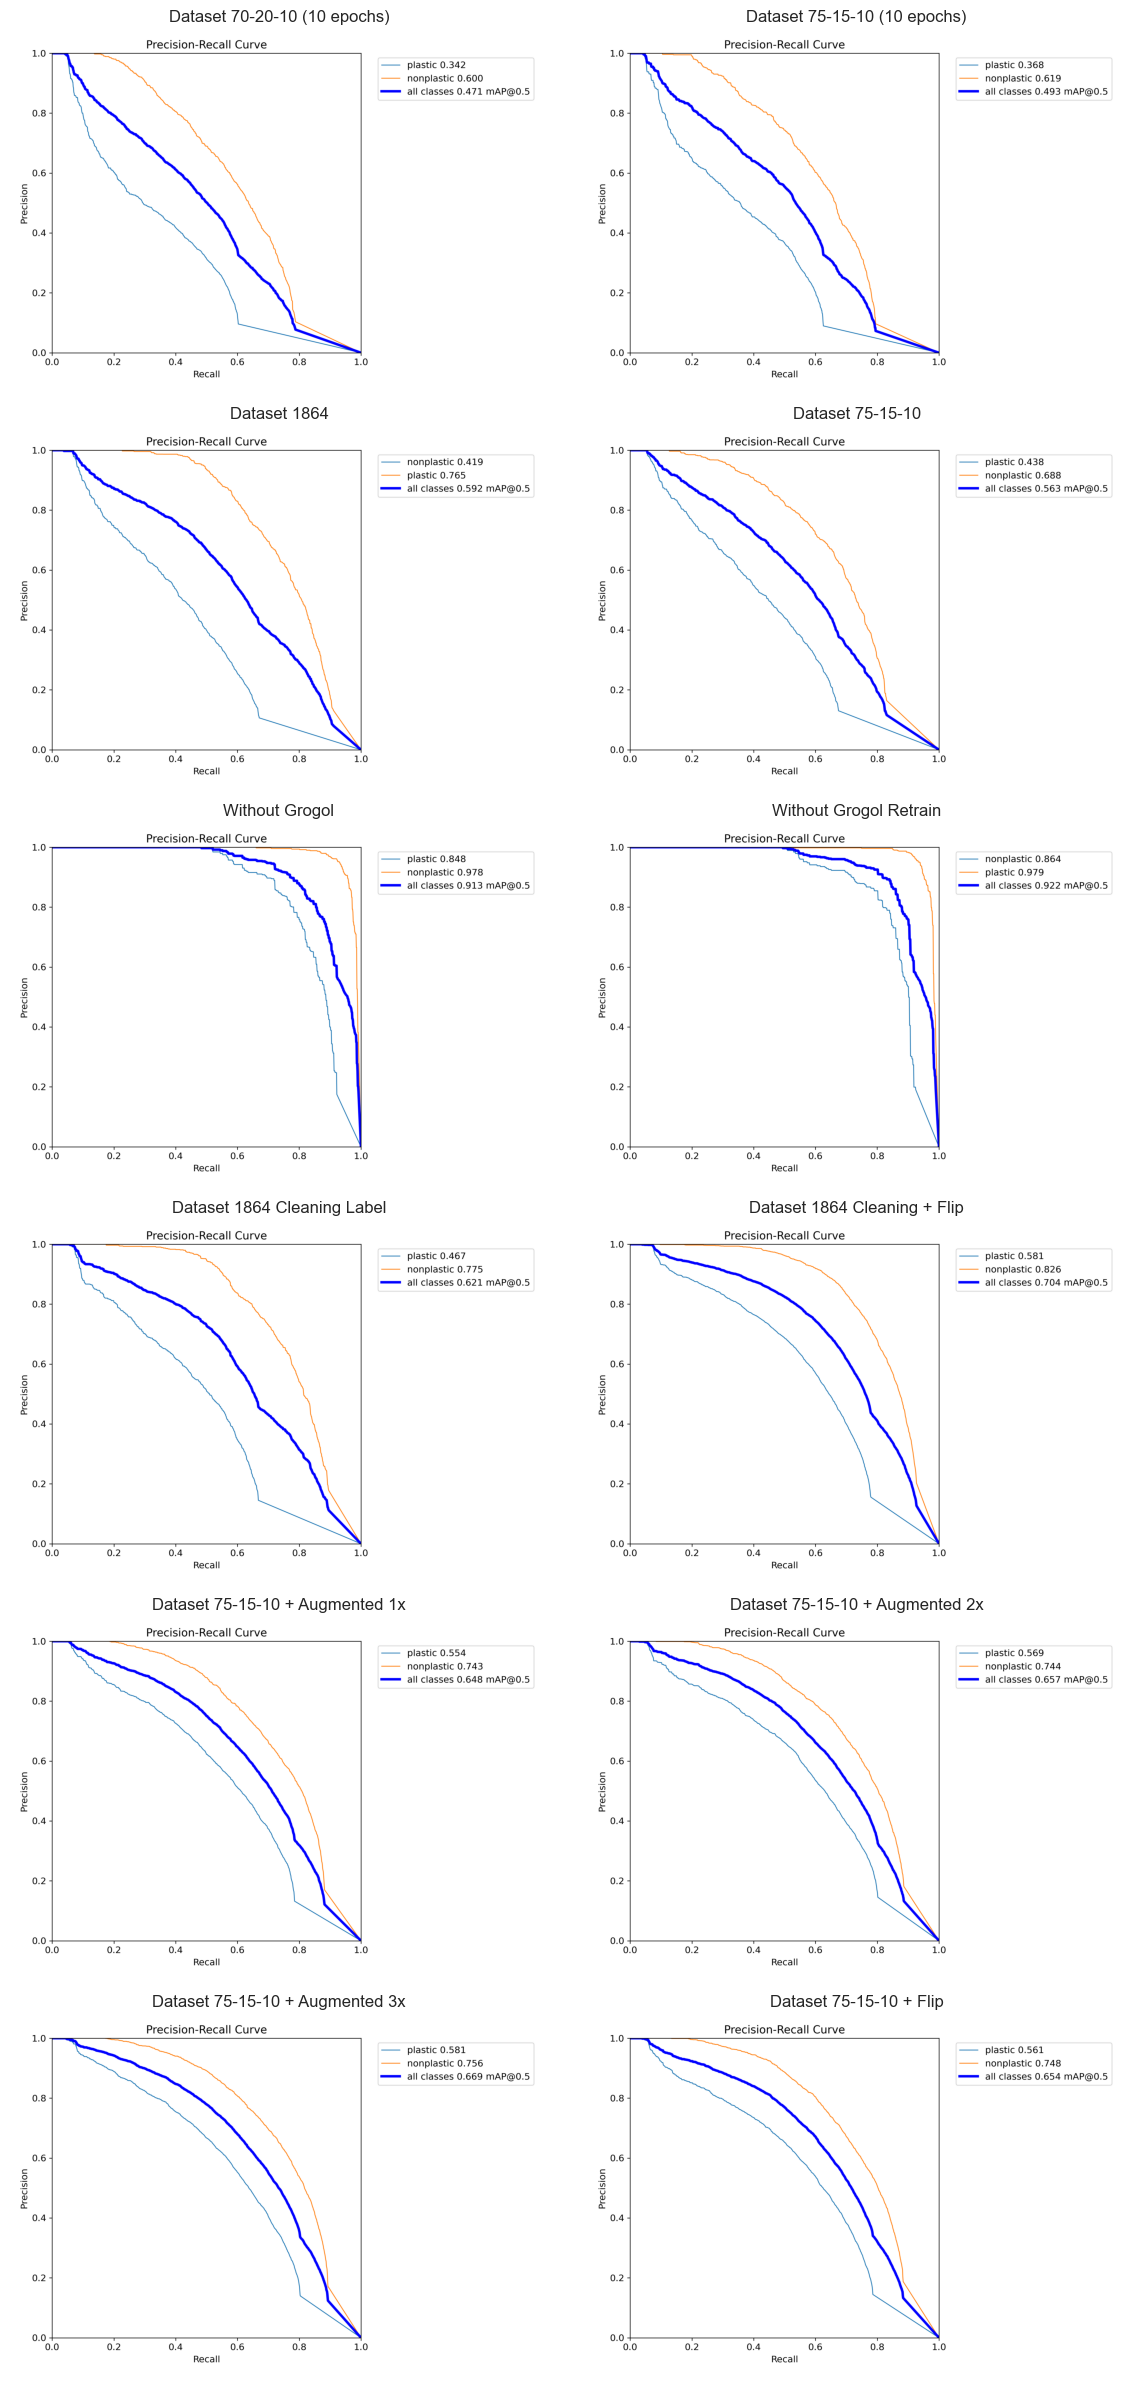

In [16]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# List path gambar PR_curve.png
image_paths = [
    "runs/d_70_20_10_train/y11n_batch16_epochs10/PR_curve.png",
    "runs/d_75_15_10_train/y11n_batch16_epochs10/PR_curve.png",
    "runs/d_train/y11n_batch16_epochs100_val/PR_curve.png",
    "runs/d_75_15_10_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/withoutgrogol_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/withoutgrogol_retrain/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_clean_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_clean_flip_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_75_15_10_augmented_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_75_15_10_augmented_2x_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_75_15_10_augmented_3x_train/y11n_batch16_epochs100/PR_curve.png",
    "runs/dataset_75_15_10_flip_train/y11n_batch16_epochs100/PR_curve.png",
]

labels = [
    "Dataset 70-20-10 (10 epochs)",
    "Dataset 75-15-10 (10 epochs)",
    "Dataset 1864",
    "Dataset 75-15-10",
    "Without Grogol",
    "Without Grogol Retrain",
    "Dataset 1864 Cleaning Label",
    "Dataset 1864 Cleaning + Flip",
    "Dataset 75-15-10 + Augmented 1x",
    "Dataset 75-15-10 + Augmented 2x",
    "Dataset 75-15-10 + Augmented 3x",
    "Dataset 75-15-10 + Flip",
]

# Hitung jumlah baris
rows = (len(image_paths) + 1) // 2

# Ukuran figure menyesuaikan jumlah baris
plt.figure(figsize=(12, rows * 4))

# Loop setiap gambar dan tampilkan
for i, img_path in enumerate(image_paths):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.subplot(rows, 2, i + 1)
        plt.imshow(img)
        plt.title(labels[i] if i < len(labels) else f'PR Curve {i+1}')
        plt.axis('off')
    else:
        print(f"Gambar tidak ditemukan: {img_path}")

plt.tight_layout()
plt.show()

### Perbandingan Hasil results.png

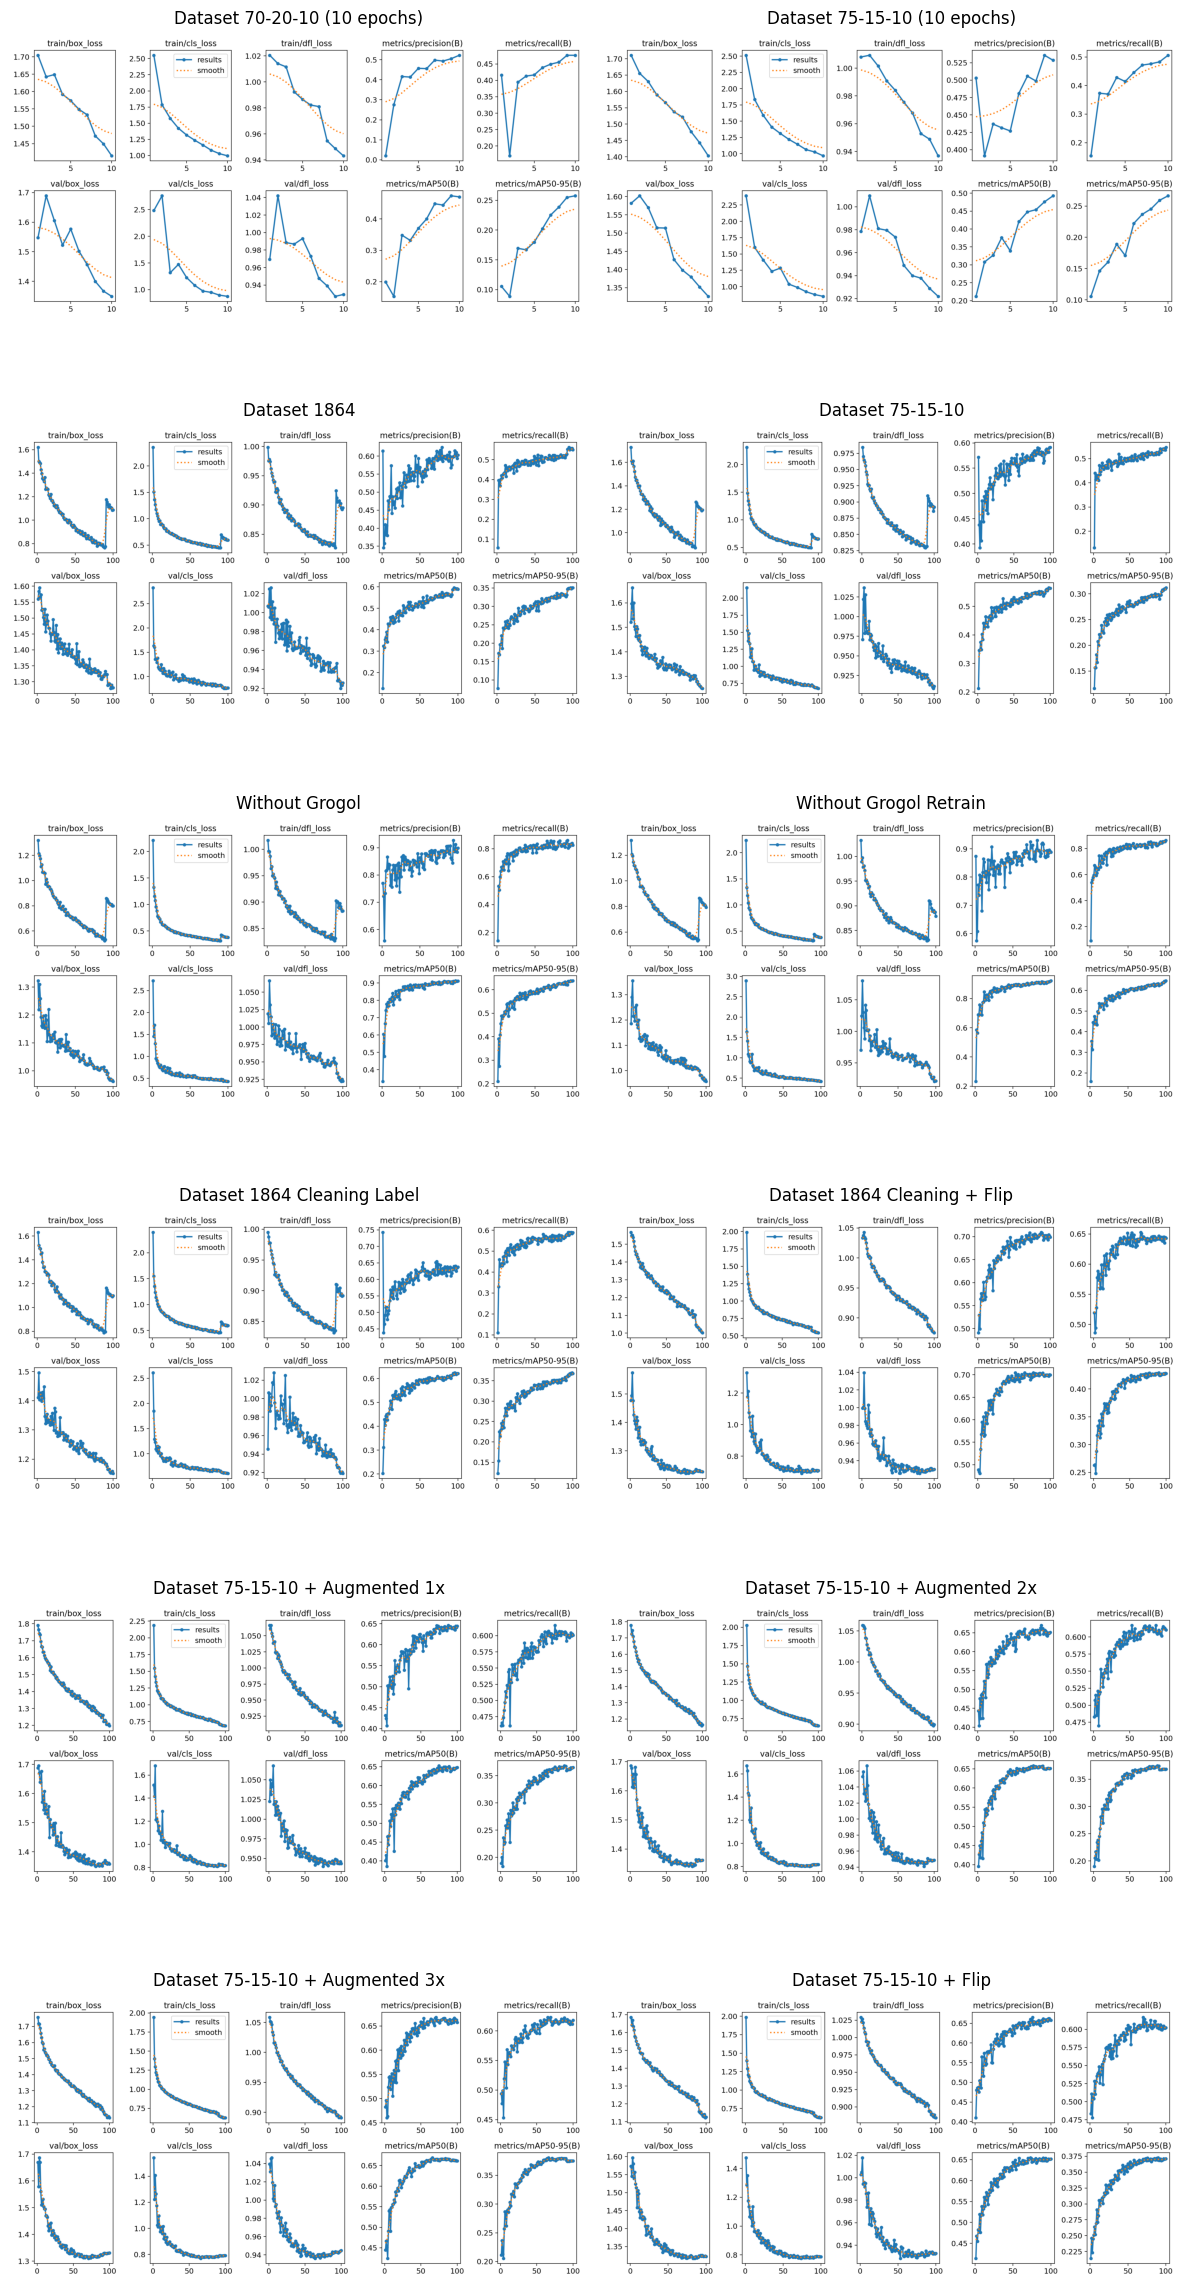

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

image_paths = [
    "runs/d_70_20_10_train/y11n_batch16_epochs10/results.png",
    "runs/d_75_15_10_train/y11n_batch16_epochs10/results.png",
    "runs/d_train/y11n_batch16_epochs100_val/results.png",
    "runs/d_75_15_10_train/y11n_batch16_epochs100/results.png",
    "runs/withoutgrogol_train/y11n_batch16_epochs100/results.png",
    "runs/withoutgrogol_retrain/y11n_batch16_epochs100/results.png",
    "runs/dataset_clean_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_clean_flip_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_75_15_10_augmented_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_75_15_10_augmented_2x_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_75_15_10_augmented_3x_train/y11n_batch16_epochs100/results.png",
    "runs/dataset_75_15_10_flip_train/y11n_batch16_epochs100/results.png",
]

labels = [
    "Dataset 70-20-10 (10 epochs)",
    "Dataset 75-15-10 (10 epochs)",
    "Dataset 1864",
    "Dataset 75-15-10",
    "Without Grogol",
    "Without Grogol Retrain",
    "Dataset 1864 Cleaning Label",
    "Dataset 1864 Cleaning + Flip",
    "Dataset 75-15-10 + Augmented 1x",
    "Dataset 75-15-10 + Augmented 2x",
    "Dataset 75-15-10 + Augmented 3x",
    "Dataset 75-15-10 + Flip",
]

# Hitung jumlah baris
rows = (len(image_paths) + 1) // 2

# Ukuran figure menyesuaikan jumlah baris
plt.figure(figsize=(12, rows * 4))

# Loop setiap gambar dan tampilkan
for i, img_path in enumerate(image_paths):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        plt.subplot(rows, 2, i + 1)
        plt.imshow(img)
        plt.title(labels[i] if i < len(labels) else f'PR Curve {i+1}')
        plt.axis('off')
    else:
        print(f"Gambar tidak ditemukan: {img_path}")

plt.tight_layout()
plt.show()